In [1]:
# Packages
import pyomo.environ as pyo
from pyomo.environ import quicksum
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import time
import os
import copy
from collections import defaultdict
from datetime import datetime
import seaborn as sns
from matplotlib import rcParams

In [2]:
# Model Controllers (False: Deactivated, True: Activated)
Price_Tech_Clustering = True 
Elec_Gas_Coupling = True # Should be False if Price_Tech_Clustering is False
MGA = False # Should be False if Price_Tech_Clustering is False

In [3]:
# Load Data
start_time = time.time()
with open('Input Data/Multi (Year)/G_Offers.pkl', 'rb') as f1, \
     open('Input Data/Multi (Year)/D_Bids.pkl', 'rb') as f2, \
     open('Input Data/Multi (Year)/G_Offers3.pkl', 'rb') as f3:
    G_Offers = pickle.load(f1)
    D_Bids = pickle.load(f2)
    G_Offers2 = pickle.load(f3)

# Add Missing Samples
date = "31/03/2024"
D_Bids[date][24] = copy.deepcopy(D_Bids[date][23])
G_Offers[date][24] = copy.deepcopy(G_Offers[date][23])
G_Offers2[date][24] = copy.deepcopy(G_Offers2[date][23])

In [4]:
# Find Min and Max MCP Prices
start_time = time.time()
min_price_ES = float('inf')
max_price_ES = float('-inf')
min_price_PT = float('inf')
max_price_PT = float('-inf')
for data in D_Bids.values():
    for D_hour in data.values():
        es = D_hour.get('Spain')
        if es:
            arr = np.concatenate([np.asarray(entry['market_clearing_price']) for entry in es.values()])
            min_price_ES = min(min_price_ES, arr.min())
            max_price_ES = max(max_price_ES, arr.max())
        pt = D_hour.get('Portugal')
        if pt:
            arr = np.concatenate([np.asarray(entry['market_clearing_price']) for entry in pt.values()])
            min_price_PT = min(min_price_PT, arr.min())
            max_price_PT = max(max_price_PT, arr.max())
print("\nExecution time:", time.time() - start_time, "seconds")


Execution time: 0.1999361515045166 seconds


In [5]:
# Filtering Input Data
start_time = time.time()
N_T=24
chosen_month_years = [
    "01/2024", 
    "02/2024", 
    "03/2024", 
    "04/2024", 
    "05/2024", 
    "06/2024",
    "07/2024", 
    "08/2024", 
    "09/2024", 
    "10/2024", 
    "11/2024", 
    "12/2024"
]
month_days_2024 = {
    "01/2024": 31,
    "02/2024": 29, 
    "03/2024": 31,
    "04/2024": 30,
    "05/2024": 31,
    "06/2024": 30,
    "07/2024": 31,
    "08/2024": 31,
    "09/2024": 30,
    "10/2024": 31,
    "11/2024": 30,
    "12/2024": 31
}
def build_selected_dates(chosen_month_years, month_days_2024):
    return {
        f"{d:02d}/{my[0:2]}/{my[3:]}"
        for my in chosen_month_years
        for d in range(1, int(month_days_2024.get(my, 0)) + 1)
    }
SELECTED_DATES = build_selected_dates(chosen_month_years, month_days_2024)
def filter_date_hour(data, selected_dates, n_t):
    return {
        date: {
            t: payload for t, payload in hours_dict.items()
            if (lambda ti: ti is not None and 1 <= ti <= n_t)(
                int(t) if isinstance(t, (str, int)) and str(t).isdigit() else None
            )
        }
        for date, hours_dict in data.items()
        if date in selected_dates and any(
            (lambda ti: ti is not None and 1 <= ti <= n_t)(
                int(t) if isinstance(t, (str, int)) and str(t).isdigit() else None
            ) for t in hours_dict.keys()
        )
    }
G_Offers  = filter_date_hour(G_Offers,  SELECTED_DATES, N_T)
D_Bids    = filter_date_hour(D_Bids,    SELECTED_DATES, N_T)
G_Offers2 = filter_date_hour(G_Offers2, SELECTED_DATES, N_T)
print("Kept dates:", sorted(G_Offers.keys()))
print("Example hours kept:", sorted(next(iter(G_Offers.values())).keys()) if G_Offers else "none")
print("\nExecution time:", time.time() - start_time, "seconds")

Kept dates: ['01/01/2024', '01/02/2024', '01/03/2024', '01/04/2024', '01/05/2024', '01/06/2024', '01/07/2024', '01/08/2024', '01/09/2024', '01/10/2024', '01/11/2024', '01/12/2024', '02/01/2024', '02/02/2024', '02/03/2024', '02/04/2024', '02/05/2024', '02/06/2024', '02/07/2024', '02/08/2024', '02/09/2024', '02/10/2024', '02/11/2024', '02/12/2024', '03/01/2024', '03/02/2024', '03/03/2024', '03/04/2024', '03/05/2024', '03/06/2024', '03/07/2024', '03/08/2024', '03/09/2024', '03/10/2024', '03/11/2024', '03/12/2024', '04/01/2024', '04/02/2024', '04/03/2024', '04/04/2024', '04/05/2024', '04/06/2024', '04/07/2024', '04/08/2024', '04/09/2024', '04/10/2024', '04/11/2024', '04/12/2024', '05/01/2024', '05/02/2024', '05/03/2024', '05/04/2024', '05/05/2024', '05/06/2024', '05/07/2024', '05/08/2024', '05/09/2024', '05/10/2024', '05/11/2024', '05/12/2024', '06/01/2024', '06/02/2024', '06/03/2024', '06/04/2024', '06/05/2024', '06/06/2024', '06/07/2024', '06/08/2024', '06/09/2024', '06/10/2024', '06/11/

In [6]:
# Load Gas Prices
start_time = time.time()
df = pd.read_excel(
    'Input Data/MIBGAS_Data_2024.xlsx',
    sheet_name='MIBGAS Indexes',
    usecols=[0, 1],
    header=None,
    names=['Date', 'Value'],
    skiprows=1
)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df = df.sort_values('Date', ignore_index=True)
_valuemin = df['Value'].min()
_valuemax = df['Value'].max()
_valuemean = df['Value'].mean()
mibgas_values_sorted = df
v = df['Value']
mibgas_values_sorted['Normalized_min'] = v / _valuemin
mibgas_values_sorted['Normalized_max'] = v / _valuemax
mibgas_values_sorted['Normalized_mean'] = v / _valuemean
selected_date_objs = set(
    pd.to_datetime(d, dayfirst=True, errors='coerce')
    for d in SELECTED_DATES
)

# Filter Gas Prices
df = df[df['Date'].isin(selected_date_objs)].reset_index(drop=True)
mibgas_values_sorted = mibgas_values_sorted[mibgas_values_sorted['Date'].isin(selected_date_objs)].reset_index(drop=True)
print("\nExecution time:", time.time() - start_time, "seconds")


Execution time: 2.9161953926086426 seconds


In [7]:
# Algorithm 1 (Based on Market Clearing Prices)
start_time = time.time()
N_B = 20
all_bids_ES = []
all_bids_PT = []
all_border_exp = []
def parse_calendar_date(date_str):
    if isinstance(date_str, datetime):
        return date_str
    try:
        return datetime.strptime(date_str, "%d/%m/%Y")
    except Exception:
        try:
            return datetime.strptime(date_str, "%Y-%m-%d")
        except Exception:
            return pd.to_datetime(date_str, dayfirst=True, errors='coerce')
sorted_dates = sorted(D_Bids.keys(), key=parse_calendar_date)
for selected_date in sorted_dates:
    D_sel = D_Bids[selected_date]
    for t in D_sel:
        D_hour = D_sel[t]
        es = D_hour.get('Spain')
        pt = D_hour.get('Portugal')
        if es:
            for entry in es.values():
                arr = np.asarray(entry['market_clearing_price'])
                all_bids_ES.extend(arr)
                all_border_exp.extend(np.asarray(entry['border_exchange']))
        if pt:
            for entry in pt.values():
                arr = np.asarray(entry['market_clearing_price'])
                all_bids_PT.extend(arr)

# Spain Clustering
if all_bids_ES:
    min_price = min_price_ES
    max_price = max_price_ES
    print('Zone: Spain')
    print(f"Minimum price value: {min_price}")
    print(f"Maximum price value: {max_price}")
slots_ES = None
slot_indices_by_datetime_ES = {}
reverse_slot_idx_map_ES = {}
slot_mode = 'equal'
if all_bids_ES:
    if slot_mode == 'equal':
        slots_ES = np.linspace(min_price, max_price, N_B + 1)
    elif slot_mode == 'random':
        rng = np.random.default_rng(seed=42)
        slot_width = (max_price - min_price) / N_B
        deviations = rng.uniform(-1, 1, N_B - 1) * slot_width
        boundaries = np.cumsum(np.full(N_B-1, slot_width) + deviations)
        boundaries = np.clip(boundaries, 0, max_price - min_price)
        slots_ES = np.array([min_price] + list(min_price + boundaries) + [max_price])
        slots_ES[0], slots_ES[-1] = min_price, max_price
        for i in range(1, len(slots_ES)):
            if slots_ES[i] <= slots_ES[i-1]:
                slots_ES[i] = slots_ES[i-1] + 1e-8
    else:
        raise ValueError(f"Unknown slot_mode: {slot_mode}")
    for selected_date in D_Bids:
        d_sel = D_Bids[selected_date]
        for t in d_sel:
            es = d_sel[t].get('Spain')
            if es:
                for entry in es.values():
                    mcp_prices = np.asarray(entry['market_clearing_price'])
                    indices = np.digitize(mcp_prices, slots_ES, right=False) - 1
                    indices = np.clip(indices, 0, len(slots_ES) - 2)
                    dt_key = (selected_date, t)
                    for idx in np.unique(indices):
                        slot_indices_by_datetime_ES.setdefault(idx, []).append(dt_key)
    for idx in sorted(slot_indices_by_datetime_ES):
        slot_min, slot_max = slots_ES[idx], slots_ES[idx + 1] if idx + 1 < len(slots_ES) else slots_ES[-1]
        dts = set(slot_indices_by_datetime_ES[idx])
        if slot_max <= slot_min:
            print(f"Slot {idx+1}: [{slot_min:.2f}, {slot_max:.2f}) -> Date/Times: {dts} (INVALID: min >= max!)")
        else:
            print(f"Slot {idx+1}: [{slot_min:.2f}, {slot_max:.2f}) -> Date/Times: {dts} (OK)")
    for slot_idx, dt_hr_list in slot_indices_by_datetime_ES.items():
        for dt, hr in dt_hr_list:
            reverse_slot_idx_map_ES.setdefault(dt, {})[hr] = slot_idx + 1

# Portugal Clustering
if all_bids_PT:
    min_price = min_price_PT
    max_price = max_price_PT
    print('\nZone: Portugal')
    print(f"Minimum price value: {min_price}")
    print(f"Maximum price value: {max_price}")
slots_PT = None
slot_indices_by_datetime_PT = {}
reverse_slot_idx_map_PT = {}
if all_bids_PT:
    if slot_mode == 'equal':
        slots_PT = np.linspace(min_price, max_price, N_B + 1)
    elif slot_mode == 'random':
        rng = np.random.default_rng(seed=42)
        slot_width = (max_price - min_price) / N_B
        deviations = rng.uniform(-1, 1, N_B - 1) * slot_width
        boundaries = np.cumsum(np.full(N_B-1, slot_width) + deviations)
        boundaries = np.clip(boundaries, 0, max_price - min_price)
        slots_PT = np.array([min_price] + list(min_price + boundaries) + [max_price])
        slots_PT[0], slots_PT[-1] = min_price, max_price
        for i in range(1, len(slots_PT)):
            if slots_PT[i] <= slots_PT[i-1]:
                slots_PT[i] = slots_PT[i-1] + 1e-8
    else:
        raise ValueError(f"Unknown slot_mode: {slot_mode}")
    for selected_date in D_Bids:
        d_sel = D_Bids[selected_date]
        for t in d_sel:
            pt = d_sel[t].get('Portugal')
            if pt:
                for entry in pt.values():
                    mc_prices = np.asarray(entry['market_clearing_price'])
                    indices = np.digitize(mc_prices, slots_PT, right=False) - 1
                    indices = np.clip(indices, 0, len(slots_PT) - 2)
                    dt_key = (selected_date, t)
                    for idx in np.unique(indices):
                        slot_indices_by_datetime_PT.setdefault(idx, []).append(dt_key)
    for idx in sorted(slot_indices_by_datetime_PT):
        slot_min, slot_max = slots_PT[idx], slots_PT[idx + 1] if idx + 1 < len(slots_PT) else slots_PT[-1]
        dts = set(slot_indices_by_datetime_PT[idx])
        if slot_max <= slot_min:
            print(f"Slot {idx+1}: [{slot_min:.2f}, {slot_max:.2f}) -> Date/Times: {dts} (INVALID: min >= max!)")
        else:
            print(f"Slot {idx+1}: [{slot_min:.2f}, {slot_max:.2f}) -> Date/Times: {dts} (OK)")
    for slot_idx, dt_hr_list in slot_indices_by_datetime_PT.items():
        for dt, hr in dt_hr_list:
            reverse_slot_idx_map_PT.setdefault(dt, {})[hr] = slot_idx + 1
G_Offers_clustered = {}
slots_dict = {'Spain': slots_ES if all_bids_ES else None, 'Portugal': slots_PT if all_bids_PT else None}
reverse_maps = {'Spain': reverse_slot_idx_map_ES, 'Portugal': reverse_slot_idx_map_PT}
for selected_date in G_Offers:
    G_Offers_clustered[selected_date] = {}
    for t in G_Offers[selected_date]:
        G_Offers_clustered[selected_date][t] = {}
        for country in G_Offers[selected_date][t]:
            slots = slots_dict[country]
            slot_idx = reverse_maps[country].get(selected_date, {}).get(t, None)
            G_Offers_clustered[selected_date][t][country] = {}
            for type in G_Offers[selected_date][t][country]:
                offers = G_Offers[selected_date][t][country][type]
                quant = np.asarray(offers['bid_quantity'])
                delivered = np.asarray(offers['activated_portion'])
                prices = np.asarray(offers['bid_price'])
                n_slots = len(slots) - 1 if slots is not None else 0
                slot_quantities = np.zeros(n_slots)
                slot_delivered = np.zeros(n_slots)
                slot_prices = np.zeros(n_slots)
                idx = (slot_idx-1) if slot_idx else None
                if idx is not None and 0 <= idx < n_slots:
                    slot_quantities[idx] = quant.sum()
                    slot_delivered[idx] = (quant * delivered).sum()/quant.sum() if quant.sum() != 0 else 0
                    slot_prices[idx] = prices.max() if prices.size else 0
                G_Offers_clustered[selected_date][t][country][type] = {
                    'bid_quantity': slot_quantities.tolist(),
                    'activated_portion': slot_delivered.tolist(),
                    'bid_price': slot_prices.tolist()
                }
G_Offers=G_Offers_clustered
print("\nExecution time:", time.time() - start_time, "seconds")

Zone: Spain
Minimum price value: -2.0
Maximum price value: 193.0
Slot 1: [-2.00, 7.75) -> Date/Times: {('23/02/2024', 2), ('23/03/2024', 22), ('12/05/2024', 17), ('18/04/2024', 1), ('08/03/2024', 18), ('08/10/2024', 12), ('21/07/2024', 16), ('29/09/2024', 16), ('26/03/2024', 19), ('13/10/2024', 16), ('16/04/2024', 1), ('01/03/2024', 5), ('24/06/2024', 12), ('26/02/2024', 2), ('19/12/2024', 4), ('28/02/2024', 3), ('17/04/2024', 6), ('05/10/2024', 16), ('22/05/2024', 17), ('01/06/2024', 13), ('31/05/2024', 8), ('09/05/2024', 12), ('21/04/2024', 24), ('08/04/2024', 10), ('23/02/2024', 15), ('06/01/2024', 16), ('13/07/2024', 14), ('10/02/2024', 17), ('12/04/2024', 16), ('09/03/2024', 23), ('18/04/2024', 14), ('06/07/2024', 11), ('05/04/2024', 18), ('07/03/2024', 4), ('22/03/2024', 16), ('27/09/2024', 6), ('28/09/2024', 13), ('23/04/2024', 10), ('08/09/2024', 13), ('09/06/2024', 16), ('24/02/2024', 2), ('16/04/2024', 14), ('07/12/2024', 15), ('23/03/2024', 12), ('24/03/2024', 17), ('04/04/2

In [8]:
# Algorithm 2 (Based on Market Clearing Prices + Technology)
if Price_Tech_Clustering:
    start_time = time.time()
    insertions_by_slot_ES = defaultdict(lambda: {'max_bids': 0, 'insertions': []})
    insertions_by_slot_PT = defaultdict(lambda: {'max_bids': 0, 'insertions': []})
    for selected_date, offers_t in G_Offers_clustered.items():
        for t, offers_c in offers_t.items():
            for country in offers_c.keys():
                if country == 'Spain':
                    slot_idx = reverse_slot_idx_map_ES.get(selected_date, {}).get(t, None)
                elif country == 'Portugal':
                    slot_idx = reverse_slot_idx_map_PT.get(selected_date, {}).get(t, None)
                else:
                    continue
                try:
                    g3_data = G_Offers2[selected_date][t][country]['Generation']
                    g3_quantities = g3_data['bid_quantity']
                    num_g3_bids = len(g3_quantities)
                except Exception:
                    g3_data = {'bid_quantity': [0.0]*N_B, 'bid_price': [0.0]*N_B, 'activated_portion': [0.0]*N_B}
                    g3_quantities = g3_data['bid_quantity']
                    num_g3_bids = len(g3_quantities)
                if num_g3_bids > 0:
                    target_dict = insertions_by_slot_ES if country == 'Spain' else insertions_by_slot_PT
                    if slot_idx not in target_dict or num_g3_bids > target_dict[slot_idx]['max_bids']:
                        target_dict[slot_idx]['max_bids'] = num_g3_bids
                    target_dict[slot_idx]['insertions'].append((selected_date, t, num_g3_bids, g3_data))
    def compute_insertions(insertions_by_slot):
        order = sorted(k for k in insertions_by_slot if k is not None)
        insertions_before_slot = {}
        cumulative = 0
        for slot_idx in order:
            insertions_before_slot[slot_idx] = cumulative
            cumulative += insertions_by_slot[slot_idx]['max_bids'] - 1
        return insertions_before_slot

    # Spain Zone
    if slots_dict['Spain'] is not None:
        insertions_before_slot_ES = compute_insertions(insertions_by_slot_ES)
        max_slots_ES = (len(slots_dict['Spain']) - 1) + sum(v['max_bids'] - 1 for v in insertions_by_slot_ES.values())
        total_insertions_ES = max_slots_ES - (len(slots_dict['Spain']) - 1)
        print('Zone: Spain')
        print(f"Found insertions at {len(insertions_by_slot_ES)} slot positions")
        print(f"Total insertions: {total_insertions_ES} slots added")
        print(f"Maximum slots needed: {max_slots_ES}")
        insertion_lookup_ES = {}
        for slot_idx, slot_data in insertions_by_slot_ES.items():
            for selected_date, t, num_bids, g3_data in slot_data['insertions']:
                insertion_lookup_ES[(selected_date, t)] = (slot_idx, slot_data['max_bids'], g3_data)

        # Thermal Blocks
        num_blocks1 = 6
        bid_block_numbers1_ES = set()
        for (selected_date, t), (insert_slot_idx, max_bids_for_slot, g3_data) in insertion_lookup_ES.items():
            if max_bids_for_slot >= num_blocks1-1:
                shifts_before = insertions_before_slot_ES.get(insert_slot_idx, 0)
                b_n = (insert_slot_idx - 1) + shifts_before + num_blocks1
                bid_block_numbers1_ES.add(b_n)

        # Target Blocks
        num_blocks2 = 6
        bid_block_numbers2_ES = set()
        for (selected_date, t), (insert_slot_idx, max_bids_for_slot, g3_data) in insertion_lookup_ES.items():
            if max_bids_for_slot >= num_blocks2-1:
                shifts_before = insertions_before_slot_ES.get(insert_slot_idx, 0)
                b_n = (insert_slot_idx - 1) + shifts_before + num_blocks2
                bid_block_numbers2_ES.add(b_n)
        bid_block_numbers1_ES = sorted(list(bid_block_numbers1_ES))
        bid_block_numbers2_ES = sorted(list(bid_block_numbers2_ES))

    # Portugal Zone
    if slots_dict['Portugal'] is not None:
        insertions_before_slot_PT = compute_insertions(insertions_by_slot_PT)
        max_slots_PT = (len(slots_dict['Portugal']) - 1) + sum(v['max_bids'] - 1 for v in insertions_by_slot_PT.values())
        total_insertions_PT = max_slots_PT - (len(slots_dict['Portugal']) - 1)
        print('\nZone: Portugal')
        print(f"Found insertions at {len(insertions_by_slot_PT)} slot positions")
        print(f"Total insertions: {total_insertions_PT} slots added")
        print(f"Maximum slots needed: {max_slots_PT}")
        insertion_lookup_PT = {}
        for slot_idx, slot_data in insertions_by_slot_PT.items():
            for selected_date, t, num_bids, g3_data in slot_data['insertions']:
                insertion_lookup_PT[(selected_date, t)] = (slot_idx, slot_data['max_bids'], g3_data)

        # Thermal Blocks
        num_blocks1 = 6
        bid_block_numbers1_PT = set()
        for (selected_date, t), (insert_slot_idx, max_bids_for_slot, g3_data) in insertion_lookup_PT.items():
            if max_bids_for_slot >= num_blocks1-1:
                shifts_before = insertions_before_slot_PT.get(insert_slot_idx, 0)
                b_n = (insert_slot_idx - 1) + shifts_before + num_blocks1
                bid_block_numbers1_PT.add(b_n)

        # Target Blocks
        num_blocks2 = 6
        bid_block_numbers2_PT = set()
        for (selected_date, t), (insert_slot_idx, max_bids_for_slot, g3_data) in insertion_lookup_PT.items():
            if max_bids_for_slot >= num_blocks2-1:
                shifts_before = insertions_before_slot_PT.get(insert_slot_idx, 0)
                b_n = (insert_slot_idx - 1) + shifts_before + num_blocks2
                bid_block_numbers2_PT.add(b_n)
        bid_block_numbers1_PT = sorted(list(bid_block_numbers1_PT))
        bid_block_numbers2_PT = sorted(list(bid_block_numbers2_PT))

    # Add New Bid Blocks
    G_Offers_clustered_expanded = {}
    for selected_date, offers_t in G_Offers_clustered.items():
        for t, offers_c in offers_t.items():
            for country, offers_country in offers_c.items():
                if country == 'Spain':
                    slot_idx = reverse_slot_idx_map_ES.get(selected_date, {}).get(t, None)
                    if slot_idx is None:
                        continue
                    max_slots = max_slots_ES
                    ins_before = insertions_before_slot_ES
                    insert_lookup = insertion_lookup_ES
                    ins_by_slot = insertions_by_slot_ES
                elif country == 'Portugal':
                    slot_idx = reverse_slot_idx_map_PT.get(selected_date, {}).get(t, None)
                    if slot_idx is None:
                        continue
                    max_slots = max_slots_PT
                    ins_before = insertions_before_slot_PT
                    insert_lookup = insertion_lookup_PT
                    ins_by_slot = insertions_by_slot_PT
                else:
                    continue
                if selected_date not in G_Offers_clustered_expanded:
                    G_Offers_clustered_expanded[selected_date] = {}
                if t not in G_Offers_clustered_expanded[selected_date]:
                    G_Offers_clustered_expanded[selected_date][t] = {}
                G_Offers_clustered_expanded[selected_date][t][country] = {}
                for type, clustered_data in offers_country.items():
                    orig_quantities = clustered_data['bid_quantity']
                    orig_delivered = clustered_data['activated_portion']
                    orig_prices = clustered_data['bid_price']
                    new_quantities = [0] * max_slots
                    new_delivered = [0] * max_slots
                    new_prices = [0] * max_slots
                    key_pair = (selected_date, t)
                    if key_pair in insert_lookup:
                        insert_slot_idx, max_bids_for_slot, g3_data = insert_lookup[key_pair]
                        shifts_before = ins_before.get(insert_slot_idx, 0)
                        insertion_pos = (insert_slot_idx - 1) + shifts_before
                        for orig_idx in range(insert_slot_idx - 1):
                            shifts_at_this_pos = sum(
                                ins_by_slot[s]['max_bids'] - 1
                                for s in ins_by_slot if s is not None and s <= (orig_idx + 1)
                            )
                            new_idx = orig_idx + shifts_at_this_pos
                            if orig_idx < len(orig_quantities) and new_idx < max_slots:
                                new_quantities[new_idx] = orig_quantities[orig_idx]
                                new_delivered[new_idx] = orig_delivered[orig_idx]
                                new_prices[new_idx] = orig_prices[orig_idx]
                        for i, (q, d, p) in enumerate(zip(g3_data['bid_quantity'], g3_data['activated_portion'], g3_data['bid_price'])):
                            idx = insertion_pos + i
                            if idx < max_slots:
                                new_quantities[idx] = q
                                new_delivered[idx] = d
                                new_prices[idx] = p
                        for orig_idx in range(insert_slot_idx, len(orig_quantities)):
                            shifts_at_this_pos = sum(
                                ins_by_slot[s]['max_bids'] - 1
                                for s in ins_by_slot if s is not None and s <= (orig_idx + 1)
                            )
                            new_idx = orig_idx + shifts_at_this_pos
                            if new_idx < max_slots:
                                new_quantities[new_idx] = orig_quantities[orig_idx]
                                new_delivered[new_idx] = orig_delivered[orig_idx]
                                new_prices[new_idx] = orig_prices[orig_idx]
                    else:
                        for orig_idx in range(len(orig_quantities)):
                            shifts_at_this_pos = sum(
                                ins_by_slot[s]['max_bids'] - 1
                                for s in ins_by_slot if s is not None and s <= (orig_idx + 1)
                            )
                            new_idx = orig_idx + shifts_at_this_pos
                            if new_idx < max_slots:
                                new_quantities[new_idx] = orig_quantities[orig_idx]
                                new_delivered[new_idx] = orig_delivered[orig_idx]
                                new_prices[new_idx] = orig_prices[orig_idx]
                    G_Offers_clustered_expanded[selected_date][t][country][type] = {
                        'bid_quantity': new_quantities,
                        'activated_portion': new_delivered,
                        'bid_price': new_prices
                    }
    G_Offers = G_Offers_clustered_expanded
    print("\nExecution time:", time.time() - start_time, "seconds")

Zone: Spain
Found insertions at 20 slot positions
Total insertions: 180 slots added
Maximum slots needed: 200

Zone: Portugal
Found insertions at 20 slot positions
Total insertions: 180 slots added
Maximum slots needed: 200

Execution time: 2.0103566646575928 seconds


In [9]:
# Generate Final Bids/Offers
start_time = time.time()
Q_init_Spain = {}
Q_init_Portugal = {}
lambda_init_Spain = {}
lambda_init_Portugal = {}
X_init_Spain = {}
X_init_Portugal = {}
dd = 0
for chosen_month_year in chosen_month_years:
    N_D = month_days_2024.get(chosen_month_year, 0)
    for d in range(1, N_D+1):
        dd += 1
        selected_date = f"{d:02d}/{chosen_month_year[0:2]}/{chosen_month_year[3:]}"
        for t in range(1, N_T+1):
            countries = G_Offers[selected_date][t]
            for country in countries:
                block_num = 0
                g_data = G_Offers[selected_date][t][country]
                if 'Generation' in g_data:
                    for quantity, price, delivered in zip(g_data['Generation']['bid_quantity'], g_data['Generation']['bid_price'], g_data['Generation']['activated_portion']):
                        block_num += 1
                        if country == 'Spain':
                            Q_init_Spain[block_num, dd, t] = -quantity
                            lambda_init_Spain[block_num, dd, t] = price
                            X_init_Spain[block_num, dd, t] = delivered
                        elif country == 'Portugal':
                            Q_init_Portugal[block_num, dd, t] = -quantity
                            lambda_init_Portugal[block_num, dd, t] = price
                            X_init_Portugal[block_num, dd, t] = delivered
                if t in D_Bids[selected_date] and country in D_Bids[selected_date][t]:
                    d_data = D_Bids[selected_date][t][country]
                    if 'Demand' in d_data:
                        for quantity, price, delivered in zip(d_data['Demand']['comulative_bid_quantities'], d_data['Demand']['market_clearing_price'], d_data['Demand']['comulative_activated_portions']):
                            block_num += 1
                            if country == 'Spain':
                                Q_init_Spain[block_num, dd, t] = quantity
                                lambda_init_Spain[block_num, dd, t] = price
                                X_init_Spain[block_num, dd, t] = delivered
                            elif country == 'Portugal':
                                Q_init_Portugal[block_num, dd, t] = quantity
                                lambda_init_Portugal[block_num, dd, t] = price
                                X_init_Portugal[block_num, dd, t] = delivered
N_Spain = max((b for (b, d, t) in Q_init_Spain), default=0)
N_Portugal = max((b for (b, d, t) in Q_init_Portugal), default=0)
dd = 0
Q_final = {}
lambda_final = {}
X_final = {}
for chosen_month_year in chosen_month_years:
    N_D = month_days_2024.get(chosen_month_year, 0)
    for d in range(1, N_D + 1):
        dd += 1
        for t in range(1, N_T + 1):
            for b in range(1, N_Spain + N_Portugal + 1):
                if b <= N_Spain:
                    Q_final[b,dd,t] = Q_init_Spain.get((b,dd,t), 0)
                    lambda_final[b,dd,t] = lambda_init_Spain.get((b,dd,t), 0)
                    X_final[b,dd,t] = X_init_Spain.get((b,dd,t), 0) if Q_final[b,dd,t] != 0 else 0
                else:
                    portugal_b = b - N_Spain
                    Q_final[b,dd,t] = Q_init_Portugal.get((portugal_b,dd,t), 0)
                    lambda_final[b,dd,t] = lambda_init_Portugal.get((portugal_b,dd,t), 0)
                    X_final[b,dd,t] = X_init_Portugal.get((portugal_b,dd,t), 0) if Q_final[b,dd,t] != 0 else 0
zone_mapping = [('Spain',b) for b in range(1,N_Spain+1)] + \
            [('Portugal',b) for b in range(N_Spain+1,N_Spain+N_Portugal+1)]
print("\nExecution time:", time.time() - start_time, "seconds")


Execution time: 16.648892641067505 seconds


In [10]:
# Visualization of Clustering Based on Market Clearing Prices
model_D = np.array(sorted({d for b, d, t in Q_final.keys()}), dtype=int)
model_T = np.array(sorted({t for b, d, t in Q_final.keys()}), dtype=int)
sns.set_theme(style='white')
plt.rcParams.update({
    'axes.titlesize': 20,
    'axes.labelsize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 20,
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
})
if not Price_Tech_Clustering:
    zones = ['Spain', 'Portugal']
    zone_blocks = {zone: [b for z, b in zone_mapping if z == zone] for zone in zones}
    all_plot_data = []
    for zone in zones:
        if zone == 'Spain':
            slots = [min_price_ES + i * (max_price_ES - min_price_ES) / (N_B) for i in range(N_B+1)]
            all_bids = all_bids_ES
        else:
            slots = [min_price_PT + i * (max_price_PT - min_price_PT) / (N_B) for i in range(N_B+1)]
            all_bids = all_bids_PT
        ds = list(model_D)
        ts = list(model_T)
        bs = zone_blocks[zone]
        Q_get = Q_final.get
        X_get = X_final.get
        data = []
        for d in ds:
            didx = d - 1
            for t in ts:
                tidx = t - 1
                for b in bs:
                    y_val = -Q_get((b, d, t), 0) * X_get((b, d, t), 0)
                    if y_val > 0:
                        if b < len(slots):
                            slot_price = slots[b]
                        else:
                            slot_price = slots[-1] if slots else 0
                        plot_x = all_bids[24 * didx + tidx]
                        data.append((
                            plot_x, 
                            y_val, 
                            b,   
                            f'{b}', 
                            d,     
                            t      
                        ))
        df = pd.DataFrame(data, columns=['BidValue', 'ActivatedQuantity', 'Block', 'BlockLabel', 'Day', 'Time'])
        fig, ax = plt.subplots(figsize=(16, 7))
        sns.scatterplot(
            data=df, x='BidValue', y='ActivatedQuantity', 
            ax=ax, marker='+', color='green', s=100, alpha=0.5, legend=False
        )
        ax.set_xlabel('Block Number', labelpad=15)
        ax.set_ylabel('Activated Quantity (MW)')
        for idx, v in enumerate(slots):
            ax.axvline(x=v, color='red', linestyle='-', alpha=0.7, linewidth=1)
        block_centers = [(slots[i] + slots[i + 1]) / 2 for i in range(N_B)]
        ax.set_xticks(block_centers)
        ax.set_xticklabels([f'{i+1}' for i in range(N_B)])
        ax.set_xlabel('Block Number', labelpad=15)
        ax.xaxis.set_ticks_position('bottom')
        ax.xaxis.set_label_position('bottom')
        ax.tick_params(axis='x', which='major', length=5, width=2, bottom=True, top=False)
        ax.tick_params(axis='y', which='major', length=5, width=2, left=True, right=False)
        ax.grid(False)
        ax2 = ax.twiny()
        ax2.set_xlim(ax.get_xlim())
        ax2.set_xlabel('Market Clearing Price (€/MWh)', labelpad=15)
        ax2.xaxis.set_ticks_position('top')
        ax2.xaxis.set_label_position('top')
        ax2.tick_params(axis='x', which='major', length=5, width=2, bottom=False, top=True)
        ax2.grid(False)
        handles = [
            plt.Line2D([0], [0], marker='+', color='w', markerfacecolor='green', markeredgecolor='green', markersize=15, linestyle='', label='Aggregated Bid'),
            plt.Line2D([0], [0], color='red', linestyle='-', alpha=0.7, label='Market Price Cluster Boundaries')
        ]
        ax.legend(handles=handles, loc='upper right', ncol=2, frameon=True)
        plt.tight_layout()
        plt.show()

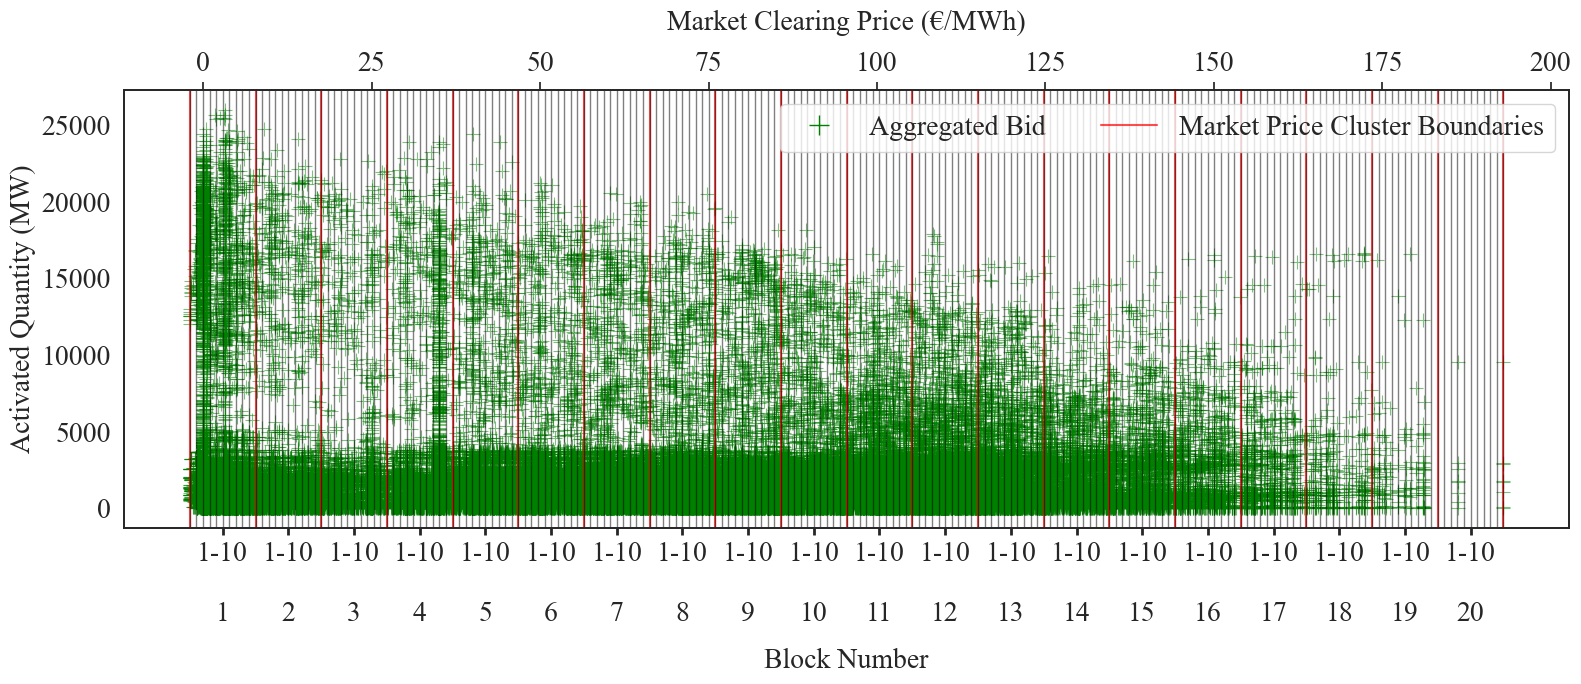

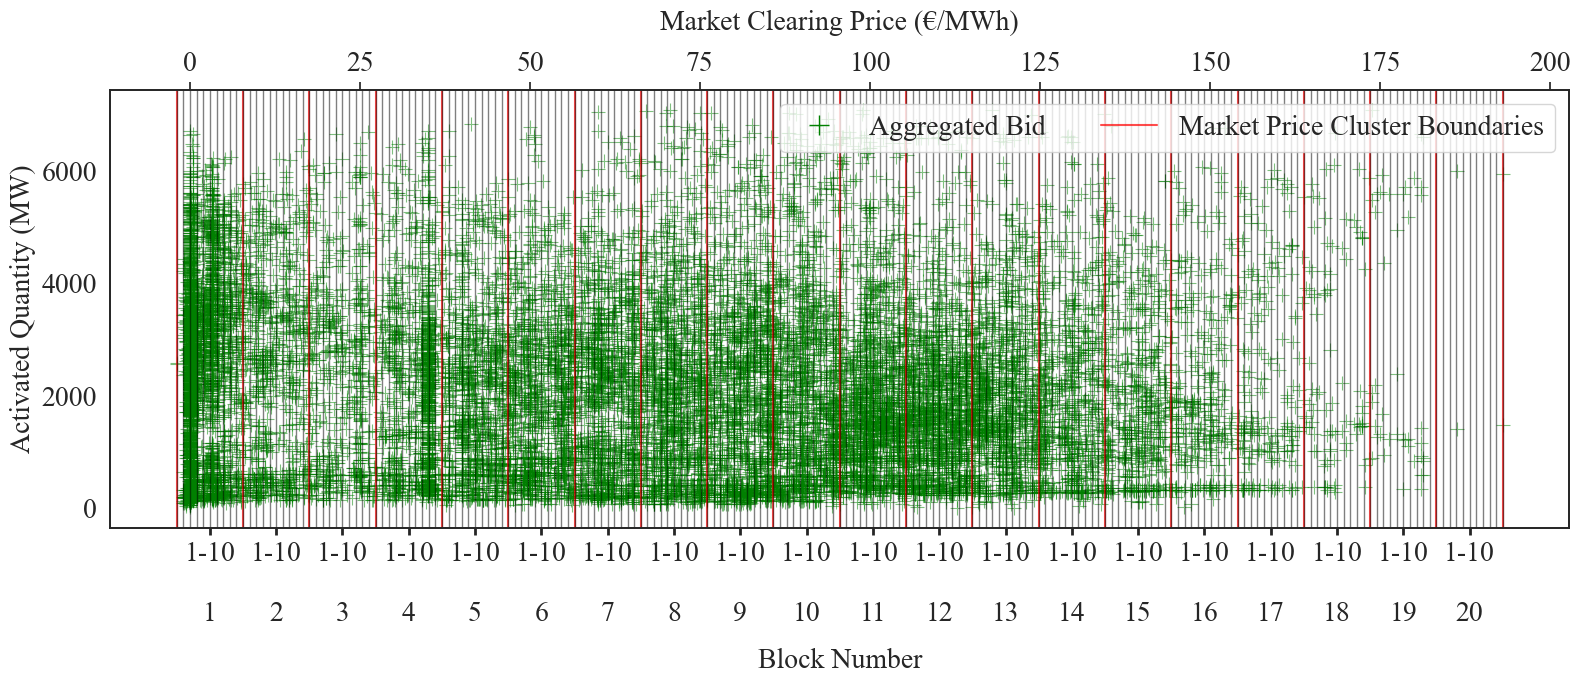

In [11]:
# Visualization of Clustering Based on Market Clearing Prices + Technology
if Price_Tech_Clustering:
    zones = ['Spain', 'Portugal']
    zone_blocks = {zone: np.array([b for z, b in zone_mapping if z == zone], dtype=int) for zone in zones}
    for zone in zones:
        if zone == 'Spain':
            slots = np.linspace(min_price_ES, max_price_ES, N_B + 1)
            all_bids = np.asarray(all_bids_ES)
        else:
            slots = np.linspace(min_price_PT, max_price_PT, N_B + 1)
            all_bids = np.asarray(all_bids_PT)
        d_grid, t_grid, b_grid = np.meshgrid(model_D, model_T, zone_blocks[zone], indexing='ij')
        d_flat = d_grid.ravel()
        t_flat = t_grid.ravel()
        b_flat = b_grid.ravel()
        q_vec = np.array([Q_final.get((b, d, t), 0) for b, d, t in zip(b_flat, d_flat, t_flat)])
        delivered_vec = np.array([X_final.get((b, d, t), 0) for b, d, t in zip(b_flat, d_flat, t_flat)])
        y_vec = -q_vec * delivered_vec
        valid_mask = y_vec > 0
        if valid_mask.sum() == 0:
            continue
        d_flat = d_flat[valid_mask]
        t_flat = t_flat[valid_mask]
        b_flat = b_flat[valid_mask]
        y_vec = y_vec[valid_mask]
        slot_index = b_flat.clip(0, len(slots)-1)
        plot_x = all_bids[(d_flat-1)*24 + (t_flat-1)]
        fig, ax = plt.subplots(figsize=(16, 7))
        sns.scatterplot(x=plot_x, y=y_vec, color='green', marker='+', alpha=0.5, s=100, ax=ax, label=f'Aggregated Bid')
        ax.set_xlabel('Block Number', labelpad=15)
        ax.set_ylabel('Activated Quantity (MW)')
        for v in slots:
            ax.axvline(x=v, color='red', linestyle='-', alpha=0.7)
        centers = (slots[:-1] + slots[1:]) / 2
        ax.set_xticks(centers)
        ax.set_xticklabels([f'1-10\n\n{i+1}' for i in range(N_B)])
        ax.set_xlabel('Block Number', labelpad=15)
        ax.xaxis.set_ticks_position('bottom')
        ax.xaxis.set_label_position('bottom')
        for tick in ax.xaxis.get_major_ticks():
            tick.tick1line.set_markersize(5)
            tick.tick1line.set_markeredgewidth(2)
        for tick in ax.yaxis.get_major_ticks():
            tick.tick1line.set_markersize(5)
            tick.tick1line.set_markeredgewidth(2)
        ax2 = ax.twiny()
        ax2.set_xlim(ax.get_xlim())
        ax2.set_xlabel('Market Clearing Price (€/MWh)', labelpad=15)
        ax2.xaxis.set_ticks_position('top')
        ax2.xaxis.set_label_position('top')
        legend = ax.legend(loc='upper right')
        if legend:
            for handle in getattr(legend, "legendHandles", []):
                try: handle.set_sizes([175])
                except Exception: pass
        if zone == 'Spain':
            more_slots = np.linspace(min_price_ES, max_price_ES, max_slots_ES+1)
        else:
            more_slots = np.linspace(min_price_PT, max_price_PT, max_slots_PT+1)
        for v in more_slots:
            ax.axvline(x=v, color='black', linestyle='-', alpha=0.5, linewidth=1)
        handles = [
            plt.Line2D([0], [0], marker='+', color='w', markerfacecolor='green', markeredgecolor='green', markersize=15, linestyle='', label='Aggregated Bid'),
            plt.Line2D([0], [0], color='red', linestyle='-', alpha=0.7, label='Market Price Cluster Boundaries')
        ]
        ax.legend(handles=handles, loc='upper right', fontsize=20, ncol=2, frameon=True)
        plt.tight_layout()
        plt.show()

In [12]:
# Solving IO Model
if not MGA:
    start_time = time.time()
    model = pyo.ConcreteModel()

    # Sets
    model.B = pyo.RangeSet(1,max(b for b,d,t in Q_final.keys()))
    model.T = pyo.RangeSet(1, N_T)
    model.Z = pyo.Set(initialize=list({country for date in D_Bids for t in D_Bids[date] for country in D_Bids[date][t]}))
    model.D = pyo.RangeSet(1,dd)
    model.L = pyo.Set(initialize=['Spain-Portugal'])

    # Parameters
    def kappa_init(m, l, z):
        start_zone, end_zone = l.split('-')
        return -1 if z==start_zone else 1 if z==end_zone else 0
    def gas_price_init(m, d, b, t):
        z = next((zone for (zone, bb) in zone_mapping if bb == b), None)
        if z == 'Spain':
            block_numbers = bid_block_numbers1_ES
        elif z == 'Portugal':
            block_numbers = [block_number + N_Spain for block_number in bid_block_numbers1_PT]
        if (b in block_numbers and pyo.value(lambda_final[b,d,t]) != 0):
            return mibgas_values_sorted.iloc[d-1]['Normalized_min']
        return 0
    model.F_max = pyo.Param(model.L, model.D, model.T, initialize=lambda m, l, d, t: all_border_exp[24*(d-1)+t-1]+1e-6*0)
    model.F_min = pyo.Param(model.L, model.D, model.T, initialize=lambda m, l, d, t: (all_border_exp[24*(d-1)+t-1]+1e-6*0))
    model.R = pyo.Param(model.L, initialize=5000)
    model.N_max = pyo.Param(model.Z, initialize=5000)
    model.N_min = pyo.Param(model.Z, initialize=-5000)
    model.Kappa = pyo.Param(model.L, model.Z, initialize=kappa_init)
    model.Q = pyo.Param(model.D, model.B, model.T, initialize=lambda m, d, b, t: Q_final.get((b,d,t), 0), default=0)
    model.X = pyo.Param(model.D, model.B, model.T, initialize=lambda m, d, b, t: X_final[b, d, t], default=0)
    model.beta_initial = pyo.Param(model.Z, model.D, model.T, initialize=lambda m, z, d, t: all_bids_ES[(d-1)*24 + t -1] if z == 'Spain' else all_bids_PT[(d-1)*24 + t -1])
    if Elec_Gas_Coupling:
        model.gas_price = pyo.Param(model.D, model.B, model.T, initialize=gas_price_init)
    else:
        model.gas_price = pyo.Param(model.D, model.B, model.T, initialize=0)

    # Variables
    model.alpha = pyo.Var(model.Z, model.D, model.T) 
    model.gamma_min = pyo.Var(model.L, model.D, model.T, within=pyo.NonNegativeReals) 
    model.gamma_max = pyo.Var(model.L, model.D, model.T, within=pyo.NonNegativeReals) 
    model.delta_min = pyo.Var(model.L, model.D, model.T, within=pyo.NonNegativeReals) 
    model.delta_max = pyo.Var(model.L, model.D, model.T, within=pyo.NonNegativeReals) 
    model.eta_min = pyo.Var(model.Z, model.D, model.T, within=pyo.NonNegativeReals) 
    model.eta_max = pyo.Var(model.Z, model.D, model.T, within=pyo.NonNegativeReals) 
    model.mu_min = pyo.Var(model.D, model.B, model.T, within=pyo.NonNegativeReals) 
    model.mu_max = pyo.Var(model.D, model.B, model.T, within=pyo.NonNegativeReals) 
    model.lambda_ = pyo.Var(model.D, model.B, model.T, within=pyo.Reals, initialize=0)
    model.gap = pyo.Var(within=pyo.Reals)
    model.abs_gap = pyo.Var(within=pyo.NonNegativeReals)
    model.lambda_IO = pyo.Var(model.Z, model.B, within=pyo.Reals, initialize=0)
    model.beta = pyo.Var(model.Z, model.D, model.T)
    model.abs_beta = pyo.Var(model.Z, model.D, model.T, within=pyo.NonNegativeReals)

    # Objective Function
    def obj_rule(m):
        return m.abs_gap + pyo.quicksum(m.abs_beta[z,d,t] for z in m.Z for d in m.D for t in m.T) 
    model.con_b1 = pyo.Objective(rule=obj_rule, sense=pyo.minimize)

    # Constraints
    def con_b2(m, d, b, t):
        z = next(z for (z,bb) in zone_mapping if bb == b)
        return (m.mu_max[d,b,t] - m.mu_min[d,b,t] - m.Q[d,b,t] * m.alpha[z,d,t] == m.lambda_[d,b,t] * m.Q[d,b,t])
    model.con_b2 = pyo.Constraint(model.D, model.B, model.T, rule=con_b2)
    def con_b3(m, l, d, t):
        if t == m.T.last():
            return (m.gamma_max[l,d,t] - m.gamma_min[l,d,t] + 
                    (m.delta_max[l,d,t] - m.delta_min[l,d,t]) - 
                    pyo.quicksum(m.Kappa[l,z] * m.beta[z,d,t] for z in m.Z) == 0)
        else:
            return (m.gamma_max[l,d,t] - m.gamma_min[l,d,t] - 
                    m.delta_max[l,d,t+1] + m.delta_min[l,d,t+1] + 
                    (m.delta_max[l,d,t] - m.delta_min[l,d,t]) - 
                    pyo.quicksum(m.Kappa[l,z] * m.beta[z,d,t] for z in m.Z) == 0)
    model.con_b3 = pyo.Constraint(model.L, model.D, model.T, rule=con_b3)
    def con_b4(m, z, d, t):
        return m.alpha[z,d,t] + m.beta[z,d,t] + m.eta_max[z,d,t] - m.eta_min[z,d,t] == 0
    model.con_b4 = pyo.Constraint(model.Z, model.D, model.T, rule=con_b4)
    def con_b5(m):
        primal_obj = pyo.quicksum(m.lambda_[d,b,t] * m.Q[d,b,t] * m.X[d,b,t] for d in m.D for b in m.B for t in m.T)
        dual_obj = pyo.quicksum(m.F_max[l,d,t] * m.gamma_max[l,d,t] - m.F_min[l,d,t] * m.gamma_min[l,d,t] 
                    for l in m.L for d in m.D for t in m.T) + \
                pyo.quicksum(m.R[l] * (m.delta_max[l,d,t] + m.delta_min[l,d,t])
                    for l in m.L for d in m.D for t in m.T) + \
                pyo.quicksum(m.N_max[z] * m.eta_max[z,d,t] - m.N_min[z] * m.eta_min[z,d,t]
                    for z in m.Z for d in m.D for t in m.T) + \
                pyo.quicksum(m.mu_max[d,b,t] for b in m.B for d in m.D for t in m.T)
        return primal_obj == dual_obj + m.gap
    model.con_b5 = pyo.Constraint(rule=con_b5)
    def con_b7(m, z, d, b, t):
        if 0 < m.X[d, b, t] < 1 and m.Q[d, b, t] < 0:
            if (z, b) in zone_mapping:
                return m.lambda_IO[z, b] == m.lambda_[d, b, t] - model.gas_price[d, b, t]**2
            else:
                return pyo.Constraint.Skip
        else:
            return pyo.Constraint.Skip
    model.con_b7 = pyo.Constraint(model.Z, model.D, model.B, model.T, rule=con_b7)
    def con_b8_I(m):
        return m.abs_gap >= m.gap
    model.con_b8_I = pyo.Constraint(rule=con_b8_I)
    def con_b8_II(m):
        return m.abs_gap >= -m.gap
    model.con_b8_II = pyo.Constraint(rule=con_b8_II)
    def con_b10_I(m, z, d, t):
        return m.abs_beta[z,d,t] >= m.beta[z,d,t] - m.beta_initial[z,d,t]
    model.con_b10_I = pyo.Constraint(model.Z, model.D, model.T, rule=con_b10_I)
    def con_b10_II(m, z, d, t):
        return m.abs_beta[z,d,t] >= -m.beta[z,d,t] + m.beta_initial[z,d,t]
    model.con_b10_II = pyo.Constraint(model.Z, model.D, model.T, rule=con_b10_II)

    # Solve IO model
    solver_IO = pyo.SolverFactory('gurobi')
    num_continuous = sum(1 for v in model.component_data_objects(pyo.Var) if v.is_continuous())
    num_binary = sum(1 for v in model.component_data_objects(pyo.Var) if v.is_binary())
    num_constraints = sum(1 for c in model.component_data_objects(pyo.Constraint, active=True))
    print(f"Number of continuous variables: {num_continuous}")
    print(f"Number of binary variables: {num_binary}")
    print(f"Number of constraints: {num_constraints}")
    dual_results = solver_IO.solve(model, tee=False)
    if dual_results.solver.status == pyo.SolverStatus.ok and dual_results.solver.termination_condition == pyo.TerminationCondition.optimal:
        print("\nOptimal solution found")
    else:
        print("Solver did not find an optimal solution")
        print("Solver status:", dual_results.solver.status)
        print("Termination condition:", dual_results.solver.termination_condition)
    print("Objective value:", pyo.value(model.con_b1))
    print("Duality Gap:", pyo.value(abs(model.gap)))
    print("\nExecution time:", time.time() - start_time, "seconds")

Number of continuous variables: 10717286
Number of binary variables: 0
Number of constraints: 3603092

Optimal solution found
Objective value: 131187.17050239377
Duality Gap: 119712.64422487942

Execution time: 626.0462975502014 seconds


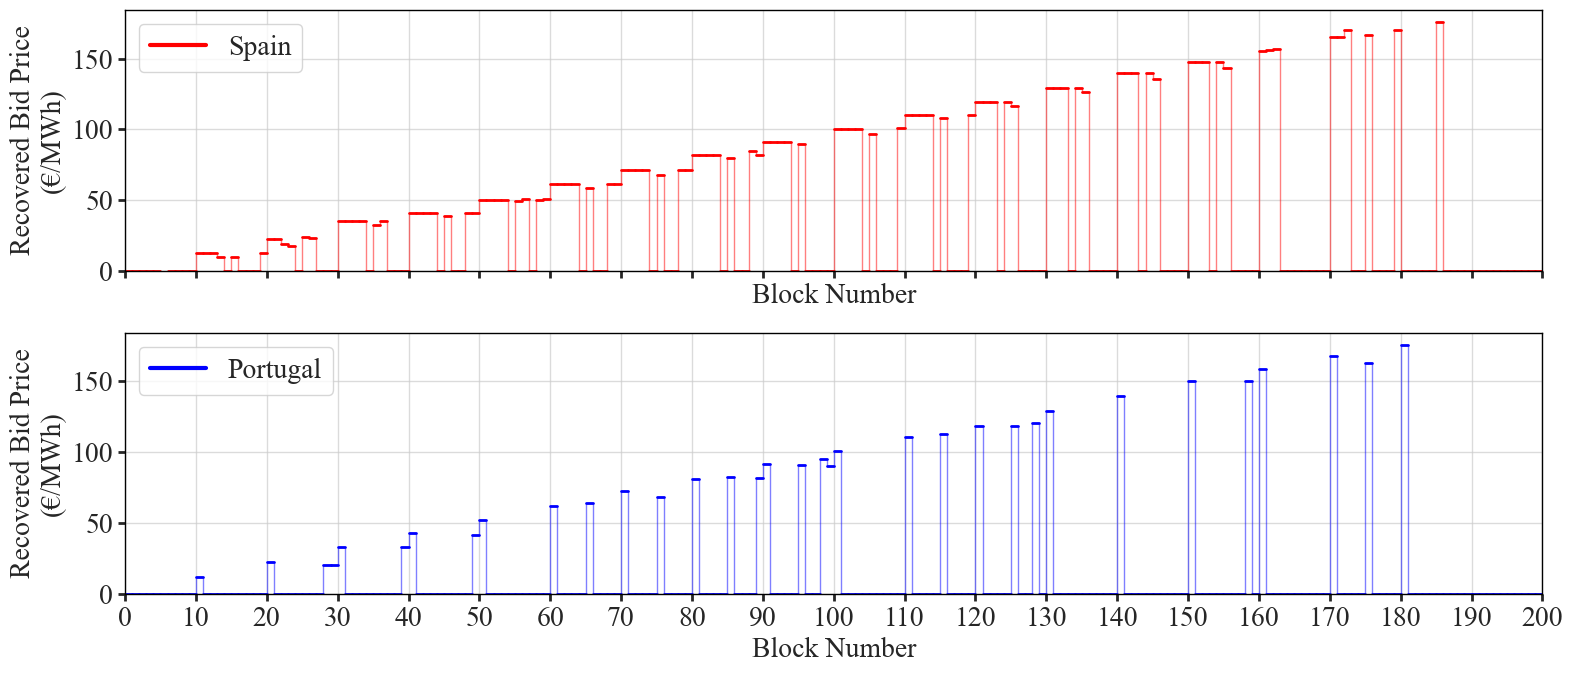

In [13]:
# IO Output (Merit Orders)
if not MGA:
    blocks = sorted(model.B)
    split_idx = N_Spain
    spain_lambda = []
    portugal_lambda = []
    for idx, b in enumerate(blocks):
        for z in model.Z:
            try:
                val = pyo.value(model.lambda_IO[z, b])
            except KeyError:
                val = float('nan')
            if z == 'Spain' and idx < split_idx - 1:
                spain_lambda.append(val)
            elif z == 'Portugal' and idx >= split_idx:
                portugal_lambda.append(val)
    if not Price_Tech_Clustering:
        block_range = np.arange(0, 21, 1)
        xtick_vals = np.arange(0, 21, 1)
    else:
        block_range = np.arange(0, 201, 1)
        xtick_vals = np.arange(0, 201, 10)
    spain_vals = spain_lambda[:-2]
    portugal_vals = portugal_lambda[:-2]
    spain_vals = list(spain_vals) + [0] * (len(block_range) - len(spain_vals))
    portugal_vals = list(portugal_vals) + [0] * (len(block_range) - len(portugal_vals))
    import seaborn as sns
    sns.set(style="whitegrid", font_scale=1.3,rc={"font.family": "Times New Roman","xtick.bottom": True,"ytick.left": True})
    fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)
    def plot_stairs(ax, x, y, color, label, for_legend=False):
        if for_legend:
            ln, = ax.plot([], [], color=color, linewidth=3, linestyle='-', label=label)
            return ln
        ax.step(x, y, where='post', color=color, linewidth=1, alpha=0.5, linestyle='-')
        for i in range(len(x)-1):
            ax.plot([x[i], x[i+1]], [y[i], y[i]], color=color, linewidth=2)
    plot_stairs(axes[0], block_range, spain_vals[:len(block_range)], color='red', label='Spain')
    spain_leg_line = plot_stairs(axes[0], block_range, spain_vals[:1], color='red', label='Spain', for_legend=True)
    if not Price_Tech_Clustering:
        axes[0].set_xlim(0, 20)
    else:
        axes[0].set_xlim(0, 200)
    axes[0].set_xticks(xtick_vals)
    axes[0].set_xlabel("Block Number", fontsize=20)
    axes[0].set_ylabel("Recovered Bid Price\n(€/MWh)", fontsize=20, fontname='Times New Roman')
    axes[0].legend(handles=[spain_leg_line], fontsize=20, loc='upper left')
    axes[0].set_ylim(bottom=0)
    axes[0].xaxis.set_ticks(xtick_vals)
    for label in (axes[0].get_xticklabels() + axes[0].get_yticklabels()):
        label.set_fontname('Times New Roman')
    plot_stairs(axes[1], block_range, portugal_vals[:len(block_range)], color='blue', label='Portugal')
    portugal_leg_line = plot_stairs(axes[1], block_range, portugal_vals[:1], color='blue', label='Portugal', for_legend=True)
    if not Price_Tech_Clustering:
        axes[1].set_xlim(0, 20)
    else:
        axes[1].set_xlim(0, 200)
    axes[1].set_xticks(xtick_vals)
    axes[1].set_xlabel("Block Number", fontsize=20)
    axes[1].set_ylabel("Recovered Bid Price\n(€/MWh)", fontsize=20, fontname='Times New Roman')
    axes[1].legend(handles=[portugal_leg_line], fontsize=20, loc='upper left')
    axes[1].set_ylim(bottom=0)
    axes[1].xaxis.set_ticks(xtick_vals)
    for label in (axes[1].get_xticklabels() + axes[1].get_yticklabels()):
        label.set_fontname('Times New Roman')
    for ax in axes:
        ax.tick_params(axis='both', labelsize=20, length=5, width=2)
        ax.grid(True, linestyle='-', alpha=0.7)
        ax.set_axisbelow(True)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color("black")
            spine.set_linewidth(1)
    plt.tight_layout()
    plt.show()

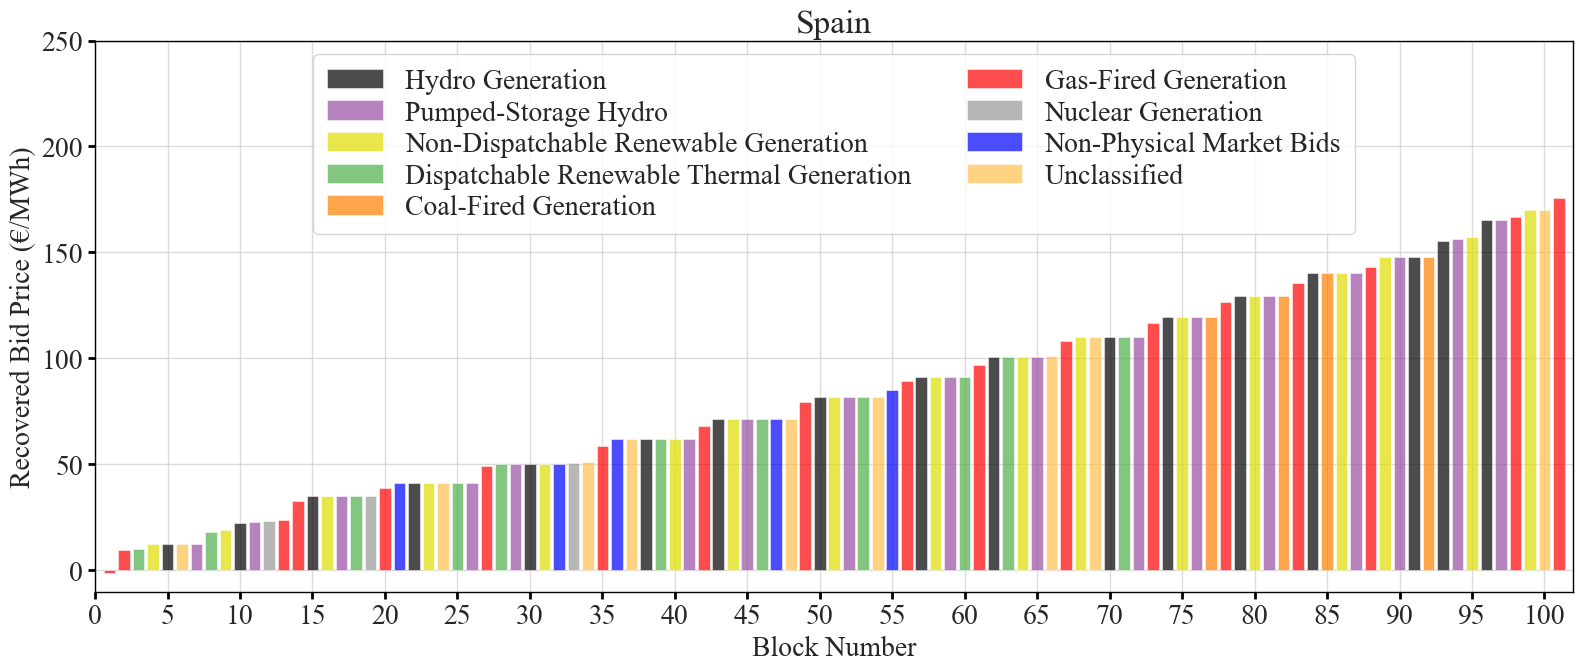

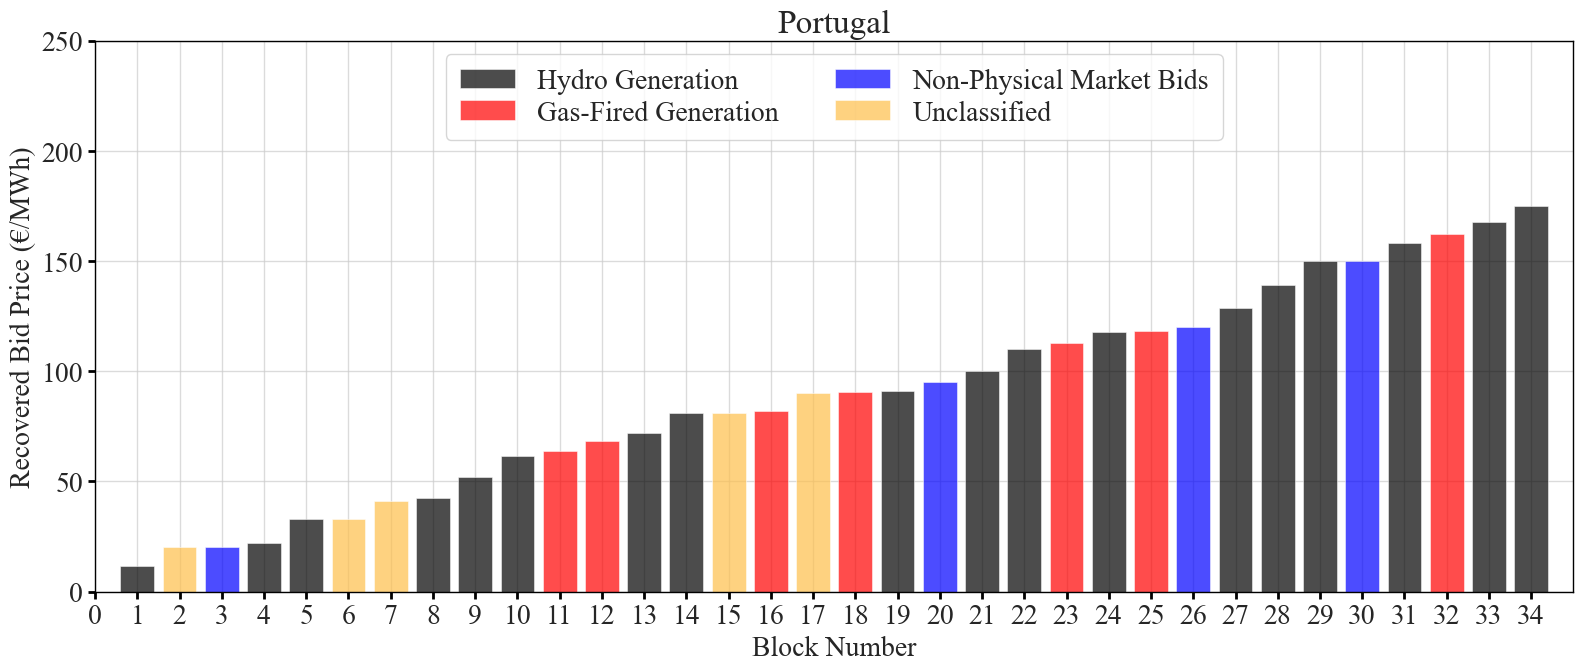

In [21]:
# IO Output (Technology Based Merit Orders)
if not MGA:
    if Price_Tech_Clustering:
        for lambdas, country, bar_color in [
            (np.array(spain_lambda[:-2]), 'Spain', 'blue'),
            (np.array(portugal_lambda[:-2]), 'Portugal', 'red'),
        ]:
            data = np.array(lambdas)
            non_zero_idx = np.where(data != 0)[0]
            data = data[non_zero_idx]
            sorted_data = []
            sorted_idx = []
            ranges = [(0,199),(201,400)]
            group_size = 10
            for rstart, rend in ranges:
                length = rend - rstart + 1
                num_groups = int(np.ceil(length / group_size))
                for group in range(num_groups):
                    start = rstart + group * group_size
                    end = min(start + group_size, rend + 1)
                    sel = [i for i in non_zero_idx if start <= i < end]
                    if not sel:
                        continue
                    group_slice = data[[list(non_zero_idx).index(i) for i in sel]]
                    indices = np.array(sel)
                    sorted_group_indices = indices[np.argsort(group_slice)]
                    sorted_data.extend(data[[list(non_zero_idx).index(i) for i in sorted_group_indices]])
                    sorted_idx.extend(sorted_group_indices)
            x = np.arange(len(sorted_data))
            technology_labels = [
                "Hydro Generation",
                "Pumped-Storage Hydro",
                "Non-Dispatchable Renewable Generation",
                "Dispatchable Renewable Thermal Generation",
                "Coal-Fired Generation",
                "Gas-Fired Generation",
                "Nuclear Generation",
                "Battery and Other Storage",
                "Non-Physical Market Bids",
                "Unclassified"
            ]
            tech_types = []
            for idx in np.array(sorted_idx):
                if 0 <= idx <=199:
                    tech_types.append(technology_labels[idx%group_size])
                elif 201 <= idx <=400:
                    tech_types.append(technology_labels[(idx-201)%group_size])
                else:
                    tech_types.append("Unclassified")
            distinct_palette = [
                "#000000",
                "#984ea3",
                "#dede00",
                "#4daf4a",
                "#ff7f00",
                "#FF0000",
                "#999999",
                "#f781bf",
                "#0000FF",
                "#FEBF4B"
            ]
            tech_to_color = {label: color for label, color in zip(technology_labels, distinct_palette)}
            df = pd.DataFrame({
                "Block Number": x+1,
                "IO Output (€/MWh)": sorted_data,
                "Technology": tech_types
            })
            plt.figure(figsize=(16, 7))
            ax = plt.gca()
            for i, tech in enumerate(technology_labels):
                tech_mask = df['Technology'] == tech
                if np.any(tech_mask):
                    plt.bar(
                        df.loc[tech_mask, 'Block Number'],
                        df.loc[tech_mask, 'IO Output (€/MWh)'],
                        color=tech_to_color[tech],
                        label=tech,
                        alpha=0.7,
                        edgecolor="white",
                        linewidth=0.5
                    )
            if country == 'Spain':
                xtick_step = 5
            else:
                xtick_step = 1
            non_zero_blocks = df.loc[df["Block Number"] != 0, "Block Number"]
            max_block = non_zero_blocks.max() if not non_zero_blocks.empty else 0
            plt.xlim(0, max_block + 1)
            xtick_pos = np.arange(0, int(df["Block Number"].max()) + 1, xtick_step)
            plt.xticks(xtick_pos, xtick_pos, fontname='Times New Roman', fontsize=20)
            plt.xlabel("Block Number", fontsize=20, fontname='Times New Roman')
            plt.ylabel("Recovered Bid Price (€/MWh)", fontsize=20, fontname='Times New Roman')
            plt.title(country, fontsize=24, fontname='Times New Roman')
            plt.ylim(top=250)
            plt.legend(
                fontsize=20,
                loc='upper center',
                bbox_to_anchor=(0.5, 1),
                ncol=2,
                prop={'family': 'Times New Roman', 'size': 20},
                frameon=True,
                handletextpad=0.8,
                borderpad=0.5,
                labelspacing=0.2
            )
            plt.tight_layout()
            ax.tick_params(axis='both', labelsize=20, length=5, width=2, direction='out', which='both')
            ax.grid(True, linestyle='-', alpha=0.7)
            ax.set_axisbelow(True)
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_color("black")
                spine.set_linewidth(1)
            for label in (ax.get_xticklabels() + ax.get_yticklabels()):
                label.set_fontname('Times New Roman')
                label.set_fontsize(20)
            ax.xaxis.set_tick_params(which='both', top=False, bottom=True, direction='out', length=5, width=2, color='black')
            ax.yaxis.set_tick_params(which='both', left=True, right=False, direction='out', length=5, width=2, color='black')
            plt.show()
       

In [145]:
# Save Results
if not MGA:
    index = pd.MultiIndex.from_product(
        [sorted(model.Z), sorted(model.B)],
        names=['z', 'b']
    )
    demand_index = pd.MultiIndex.from_product(
        [sorted(model.Z), sorted(model.D), sorted(model.T)],
        names=['z', 'd', 't']
    )
    data = [pyo.value(model.lambda_IO[z, b]) for z in sorted(model.Z) for b in sorted(model.B)]
    lambda_IO_df = pd.DataFrame(data, index=index, columns=['lambda_IO'])
    rows = []
    zone_lookup = {b_map: z for z, b_map in zone_mapping}
    for d in sorted(model.D):
        for t in sorted(model.T):
            positive_b = [b for b in sorted(model.B) if pyo.value(model.Q[d, b, t]) > 0]
            for b_found in positive_b:
                if b_found in zone_lookup:
                    z_found = zone_lookup[b_found]
                    val = pyo.value(model.lambda_[d, b_found, t])
                    rows.append({
                        'z': z_found,
                        'd': d,
                        't': t,
                        'demand': val
                    })
    demand_df = pd.DataFrame(rows)
    demand_df.set_index(['z', 'd', 't'], inplace=True)
    demand_df.sort_index(inplace=True)
    os.makedirs('IO Output', exist_ok=True)
    if not Elec_Gas_Coupling:
        fname = os.path.join('IO Output', 'IO-Recovered Merit Orders (No Elec-Gas Coupling).pkl')
    else:
        fname = os.path.join('IO Output', 'IO-Recovered Merit Orders (Under Elec-Gas Coupling).pkl')
    with open(fname, 'wb') as f:
        pd.to_pickle({'lambda_IO': lambda_IO_df, 'demand': demand_df, 'objective': pyo.value(model.con_b1)}, f)
    print(f"Saved results to: {fname}")

Saved results to: IO Output\IO-Recovered Merit Orders (Under Elec-Gas Coupling).pkl


In [24]:
# Load Baselines
if MGA:
    start_time = time.time()
    pickle_dir = 'IO Output'
    results_list = []
    def load_pickle_if_exists(filename):
        filepath = os.path.join(pickle_dir, filename)
        if os.path.isfile(filepath):
            with open(filepath, 'rb') as f:
                return pickle.load(f), filepath
        return None, None
    res, filepath = load_pickle_if_exists('IO-Recovered Merit Orders (Under Elec-Gas Coupling).pkl')
    if res is not None:
        results_list.append(filepath)
    lambda_IO_tilde = {}
    demand_ = {}
    for file_idx, filename in enumerate(results_list):
        with open(filename, 'rb') as f:
            result = pickle.load(f)
        z_IO = result['objective']
        for z in model.Z:
            if z == 'Spain':
                for b in list(model.B)[:N_Spain - 1]:
                    lambda_IO_tilde[(file_idx,z,b)] = result['lambda_IO']['lambda_IO'][z][b]
                for d in model.D:
                    for t in model.T:
                        demand_[(file_idx,z,d,t)] = result['demand']['demand'][z][d][t]
            elif z == 'Portugal':
                for b in list(model.B)[int(N_Spain):-1]:
                    lambda_IO_tilde[(file_idx,z,b)] = result['lambda_IO']['lambda_IO'][z][b]
                for d in model.D:
                    for t in model.T:
                        demand_[(file_idx,z,d,t)] = result['demand']['demand'][z][d][t]
    print("\nExecution time:", time.time() - start_time, "seconds")


Execution time: 4.916544675827026 seconds


In [ ]:
# Create MGA Model
if MGA:
    start_time = time.time()
    model = pyo.ConcreteModel()

    # Sets
    model.B = pyo.RangeSet(1,max(b for b,d,t in Q_final.keys()))
    model.T = pyo.RangeSet(1, N_T)
    model.Z = pyo.Set(initialize=list({country for date in D_Bids for t in D_Bids[date] for country in D_Bids[date][t]}))
    model.D = pyo.RangeSet(1,dd)
    model.L = pyo.Set(initialize=['Spain-Portugal'])

    # Parameters
    def kappa_init(m, l, z):
        start_zone, end_zone = l.split('-')
        return -1 if z==start_zone else 1 if z==end_zone else 0
    def gas_price_init(m, d, b, t):
        z = next((zone for (zone, bb) in zone_mapping if bb == b), None)
        if z == 'Spain':
            block_numbers = bid_block_numbers1_ES
        elif z == 'Portugal':
            block_numbers = [block_number + N_Spain for block_number in bid_block_numbers1_PT]
        if (b in block_numbers and pyo.value(lambda_final[b,d,t]) != 0):
            return mibgas_values_sorted.iloc[d-1]['Normalized_min']
        return 0
    model.F_max = pyo.Param(model.L, model.D, model.T, initialize=lambda m, l, d, t: all_border_exp[24*(d-1)+t-1]+1e-6*0)
    model.F_min = pyo.Param(model.L, model.D, model.T, initialize=lambda m, l, d, t: (all_border_exp[24*(d-1)+t-1]+1e-6*0))
    model.R = pyo.Param(model.L, initialize=5000)
    model.N_max = pyo.Param(model.Z, initialize=5000)
    model.N_min = pyo.Param(model.Z, initialize=-5000)
    model.Kappa = pyo.Param(model.L, model.Z, initialize=kappa_init)
    model.Q = pyo.Param(model.D, model.B, model.T, initialize=lambda m, d, b, t: Q_final.get((b,d,t), 0), default=0)
    model.X = pyo.Param(model.D, model.B, model.T, initialize=lambda m, d, b, t: X_final[b, d, t], default=0)
    model.beta_initial = pyo.Param(model.Z, model.D, model.T, initialize=lambda m, z, d, t: all_bids_ES[(d-1)*24 + t -1] if z == 'Spain' else all_bids_PT[(d-1)*24 + t -1])
    if Elec_Gas_Coupling:
        model.gas_price = pyo.Param(model.D, model.B, model.T, initialize=gas_price_init)
    else:
        model.gas_price = pyo.Param(model.D, model.B, model.T, initialize=0)   
    model.w = pyo.Param(model.B, initialize=lambda m, b: 1 if b in bid_block_numbers2_ES or (b-N_Spain) in bid_block_numbers2_PT else 0)
    model.delta_p = pyo.Param(model.B, initialize=lambda m, b: 0.0 if b in bid_block_numbers2_ES or (b-N_Spain) in bid_block_numbers2_PT else 0, mutable=True)
    model.delta_n = pyo.Param(model.B, initialize=lambda m, b: 0.0 if b in bid_block_numbers2_ES or (b-N_Spain) in bid_block_numbers2_PT else 0, mutable=True)
    model.theta_var = pyo.Param(initialize=1.6)
    model.z_IO_tilde = pyo.Param(initialize=z_IO)

    # Variables
    model.alpha = pyo.Var(model.Z, model.D, model.T) 
    model.gamma_min = pyo.Var(model.L, model.D, model.T, within=pyo.NonNegativeReals) 
    model.gamma_max = pyo.Var(model.L, model.D, model.T, within=pyo.NonNegativeReals) 
    model.delta_min = pyo.Var(model.L, model.D, model.T, within=pyo.NonNegativeReals) 
    model.delta_max = pyo.Var(model.L, model.D, model.T, within=pyo.NonNegativeReals) 
    model.eta_min = pyo.Var(model.Z, model.D, model.T, within=pyo.NonNegativeReals) 
    model.eta_max = pyo.Var(model.Z, model.D, model.T, within=pyo.NonNegativeReals) 
    model.mu_min = pyo.Var(model.D, model.B, model.T, within=pyo.NonNegativeReals) 
    model.mu_max = pyo.Var(model.D, model.B, model.T, within=pyo.NonNegativeReals) 
    model.lambda_ = pyo.Var(model.D, model.B, model.T, within=pyo.Reals, initialize=0)
    model.gap = pyo.Var(within=pyo.Reals)
    model.abs_gap = pyo.Var(within=pyo.NonNegativeReals)
    model.beta = pyo.Var(model.Z, model.D, model.T)
    model.abs_beta = pyo.Var(model.Z, model.D, model.T, within=pyo.NonNegativeReals)
    model.lambda_MGA = pyo.Var(model.Z, model.B, within=pyo.Reals, initialize=0)
    model.delta_lambda_p = pyo.Var(model.B, within=pyo.NonNegativeReals, initialize=0)
    model.delta_lambda_n = pyo.Var(model.B, within=pyo.NonNegativeReals, initialize=0)
    model.u_p = pyo.Var(model.B, within=pyo.Binary, initialize=0)
    model.u_n = pyo.Var(model.B, within=pyo.Binary, initialize=0)

    # Objective Function
    def obj_rule(m):
        z_IO = sum(m.w[b] * (m.delta_lambda_p[b] + m.delta_lambda_n[b]) for b in m.B if b != max(m.B))
        return z_IO
    model.con_c1 = pyo.Objective(rule=obj_rule, sense=pyo.maximize)

    # Constraints
    def con_c2(m, d, b, t):
        z = next(z for (z,bb) in zone_mapping if bb == b)
        return (m.mu_max[d,b,t] - m.mu_min[d,b,t] - m.Q[d,b,t] * m.alpha[z,d,t] == m.lambda_[d,b,t] * m.Q[d,b,t])
    model.con_c2 = pyo.Constraint(model.D, model.B, model.T, rule=con_c2)
    def con_c3(m, l, d, t):
        if t == m.T.last():
            return (m.gamma_max[l,d,t] - m.gamma_min[l,d,t] + 
                    (m.delta_max[l,d,t] - m.delta_min[l,d,t]) - 
                    pyo.quicksum(m.Kappa[l,z] * m.beta[z,d,t] for z in m.Z) == 0)
        else:
            return (m.gamma_max[l,d,t] - m.gamma_min[l,d,t] - 
                    m.delta_max[l,d,t+1] + m.delta_min[l,d,t+1] + 
                    (m.delta_max[l,d,t] - m.delta_min[l,d,t]) - 
                    pyo.quicksum(m.Kappa[l,z] * m.beta[z,d,t] for z in m.Z) == 0)
    model.con_c3 = pyo.Constraint(model.L, model.D, model.T, rule=con_c3)
    def con_c4(m, z, d, t):
        return m.alpha[z,d,t] + m.beta[z,d,t] + m.eta_max[z,d,t] - m.eta_min[z,d,t] == 0
    model.con_c4 = pyo.Constraint(model.Z, model.D, model.T, rule=con_c4)
    def con_c5(m):
        primal_obj = pyo.quicksum(m.lambda_[d,b,t] * m.Q[d,b,t] * m.X[d,b,t] for d in m.D for b in m.B for t in m.T)
        dual_obj = pyo.quicksum(m.F_max[l,d,t] * m.gamma_max[l,d,t] - m.F_min[l,d,t] * m.gamma_min[l,d,t] 
                    for l in m.L for d in m.D for t in m.T) + \
                pyo.quicksum(m.R[l] * (m.delta_max[l,d,t] + m.delta_min[l,d,t])
                    for l in m.L for d in m.D for t in m.T) + \
                pyo.quicksum(m.N_max[z] * m.eta_max[z,d,t] - m.N_min[z] * m.eta_min[z,d,t]
                    for z in m.Z for d in m.D for t in m.T) + \
                pyo.quicksum(m.mu_max[d,b,t] for b in m.B for d in m.D for t in m.T)
        return primal_obj == dual_obj + m.gap
    model.con_c5 = pyo.Constraint(rule=con_c5)
    def con_c6(m, z, d, b, t):
        if 0 < m.X[d, b, t] < 1 and m.Q[d, b, t] < 0:
            if (z, b) in zone_mapping:
                return m.lambda_MGA[z, b] == m.lambda_[d, b, t] - model.gas_price[d, b, t]**2
            else:
                return pyo.Constraint.Skip
        else:
            return pyo.Constraint.Skip
    model.con_c6 = pyo.Constraint(model.Z, model.D, model.B, model.T, rule=con_c6)
    def con_b8_I(m):
        return m.abs_gap >= m.gap
    model.con_b8_I = pyo.Constraint(rule=con_b8_I)
    def con_b8_II(m):
        return m.abs_gap >= -m.gap
    model.con_b8_II = pyo.Constraint(rule=con_b8_II)
    def con_b10_I(m, z, d, t):
        return m.abs_beta[z,d,t] >= m.beta[z,d,t] - m.beta_initial[z,d,t]
    model.con_b10_I = pyo.Constraint(model.Z, model.D, model.T, rule=con_b10_I)
    def con_b10_II(m, z, d, t):
        return m.abs_beta[z,d,t] >= -m.beta[z,d,t] + m.beta_initial[z,d,t]
    model.con_b10_II = pyo.Constraint(model.Z, model.D, model.T, rule=con_b10_II)
    def con_c7(m, b):
        if b in list(model.B)[:int(N_Spain) - 1]:
            return m.delta_lambda_p[b] - m.delta_lambda_n[b] == m.lambda_MGA['Spain', b] - lambda_IO_tilde[(0, 'Spain', b)]
        elif b in list(model.B)[int(N_Spain):-1]:
            return m.delta_lambda_p[b] - m.delta_lambda_n[b] == m.lambda_MGA['Portugal', b] - lambda_IO_tilde[(0, 'Portugal', b)]
        else:
            return pyo.Constraint.Skip
    model.con_c7 = pyo.Constraint(model.B, rule=con_c7)
    def con_c8(m, b):
        if b in list(model.B)[:int(N_Spain) - 1]:
            return m.delta_lambda_p[b] <= m.delta_p[b] * lambda_IO_tilde[(0, 'Spain', b)] * m.u_p[b]
        elif b in list(model.B)[int(N_Spain):-1]:
            return m.delta_lambda_p[b] <= m.delta_p[b] * lambda_IO_tilde[(0, 'Portugal', b)] * m.u_p[b]
        else:
            return pyo.Constraint.Skip
    model.con_c8 = pyo.Constraint(model.B, rule=con_c8)
    def con_c9(m, b):
        if b in list(model.B)[:int(N_Spain) - 1]:
            return m.delta_lambda_n[b] <= m.delta_n[b] * lambda_IO_tilde[(0, 'Spain', b)] * m.u_n[b]
        elif b in list(model.B)[int(N_Spain):-1]:
            return m.delta_lambda_n[b] <= m.delta_n[b] * lambda_IO_tilde[(0, 'Portugal', b)] * m.u_n[b]
        else:
            return pyo.Constraint.Skip
    model.con_c9 = pyo.Constraint(model.B, rule=con_c9)
    def con_c10(m, b):
        return m.u_p[b] + m.u_n[b] <= 1
    model.con_c10 = pyo.Constraint(model.B, rule=con_c10)
    def con_c11(m):
        return m.abs_gap + pyo.quicksum(m.abs_beta[z,d,t] for z in m.Z for d in m.D for t in m.T) <= m.theta_var * m.z_IO_tilde
    model.con_c11 = pyo.Constraint(rule=con_c11)

    # Solve IO model
    solver_MGA = pyo.SolverFactory('gurobi')
    num_continuous = sum(1 for v in model.component_data_objects(pyo.Var) if v.is_continuous())
    num_binary = sum(1 for v in model.component_data_objects(pyo.Var) if v.is_binary())
    num_constraints = sum(1 for c in model.component_data_objects(pyo.Constraint, active=True))
    print(f"Number of continuous variables: {num_continuous}")
    print(f"Number of binary variables: {num_binary}")
    print(f"Number of constraints: {num_constraints}")
    print("\nExecution time:", time.time() - start_time, "seconds")

Number of continuous variables: 10718090
Number of binary variables: 804
Number of constraints: 3604695

Execution time: 491.62065505981445 seconds


Optimal solution found


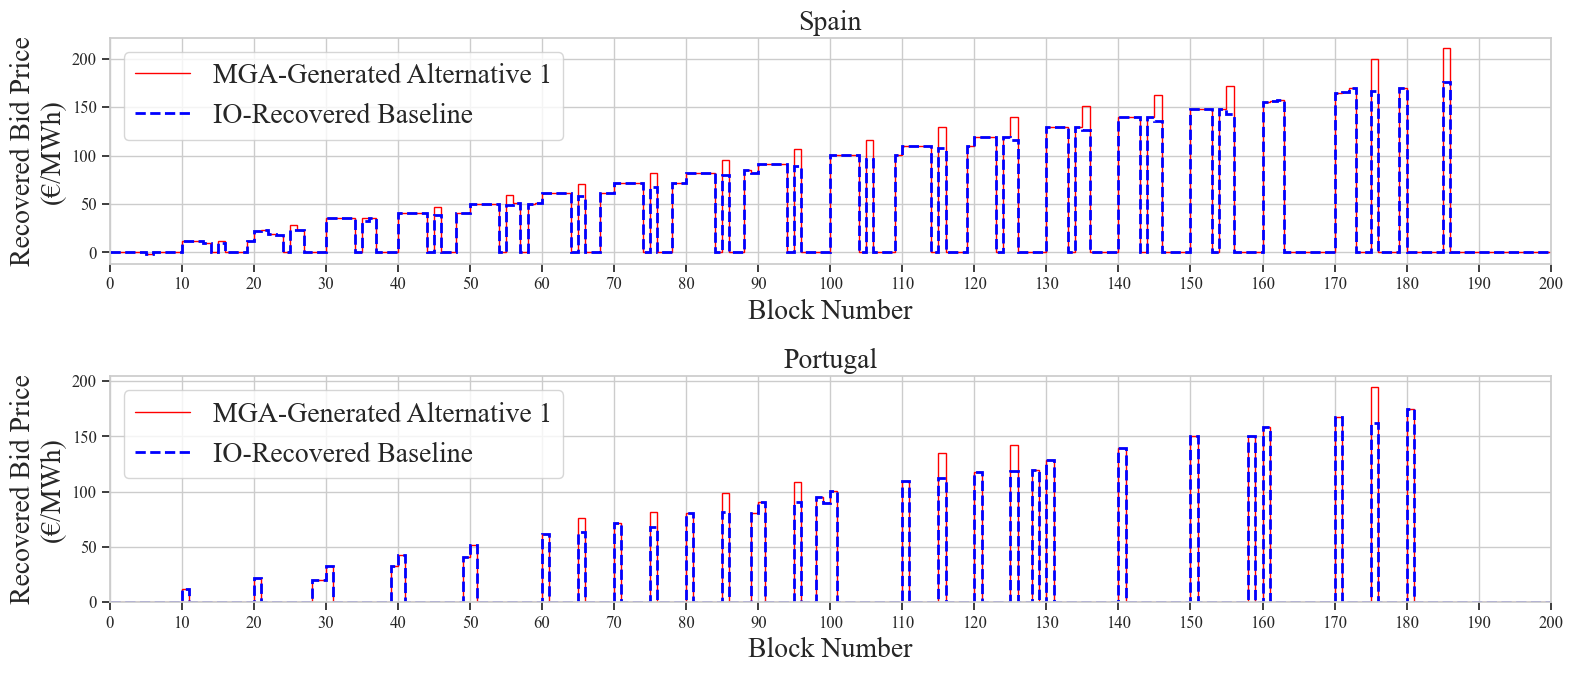

Saved results to: IO Output\Alternative 1.pkl
389.66467213630676

Execution time: 389.66467213630676 seconds
Optimal solution found


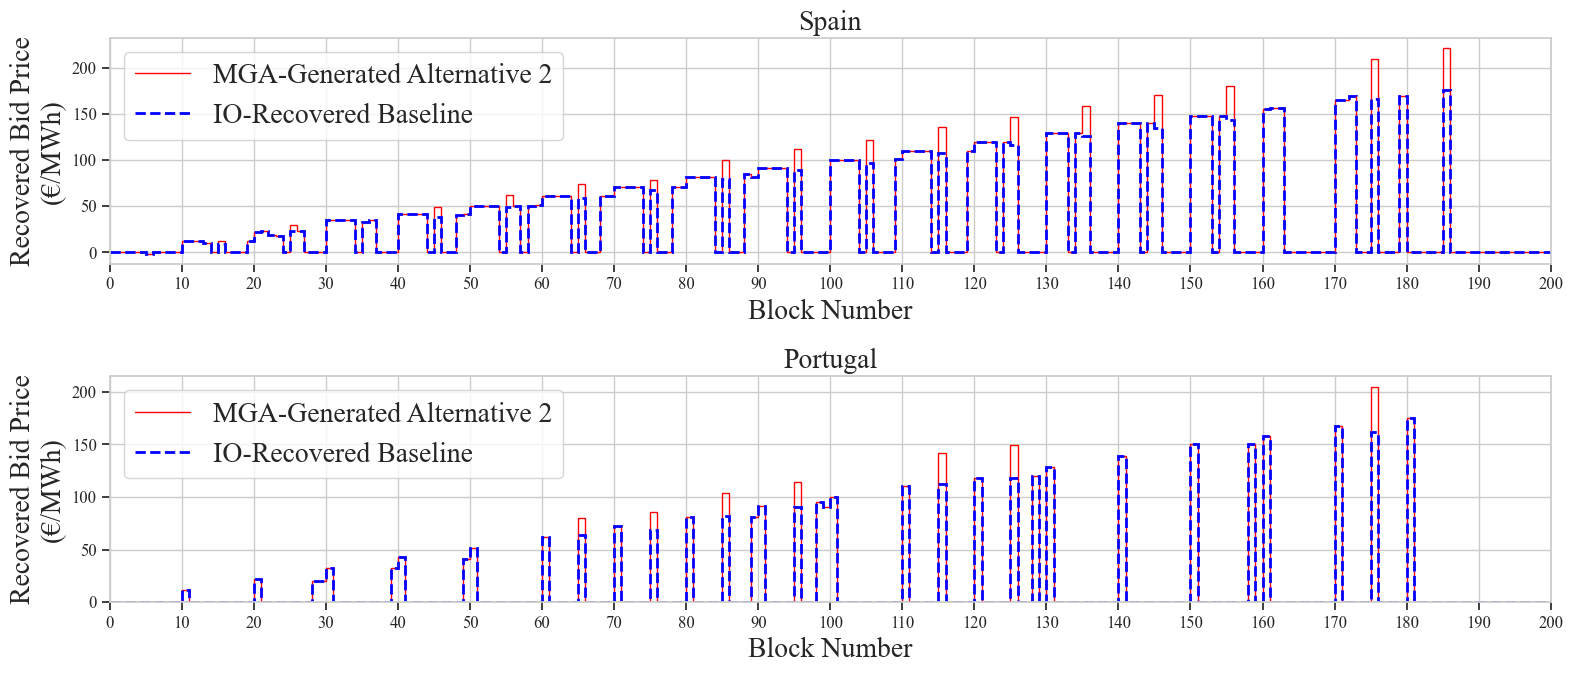

Saved results to: IO Output\Alternative 2.pkl
321.5963559150696

Execution time: 321.5963559150696 seconds


In [ ]:
# MGA Loop
for it in range(1, 3):
    start_time = time.time()
    pct_increases = [0.2, 0.26]
    ES_blocks = [b for b in model.B if b in bid_block_numbers2_ES or (b-N_Spain) in bid_block_numbers2_PT]
    if it <= 2:
        pct = pct_increases[it-1]
        for b in ES_blocks:
            model.delta_p[b] = pct
            model.delta_n[b] = 0.0
    else:
        pct = pct_increases[it-11]
        for b in ES_blocks:
            model.delta_p[b] = 0.0
            model.delta_n[b] = pct
    results = solver_MGA.solve(model, tee=False)
    blocks = sorted(model.B)
    split_idx = int(len(blocks) / 2)
    blocks_first_half = blocks[:split_idx]
    blocks_second_half = blocks[split_idx:]
    spain_lambda_MGA = []
    portugal_lambda_MGA = []
    for idx, b in enumerate(blocks):
        for z in model.Z:
            try:
                val = pyo.value(model.lambda_MGA[z, b])
            except KeyError:
                val = float('nan')
            if z == 'Spain' and idx < split_idx:
                spain_lambda_MGA.append(val)
            elif z == 'Portugal' and idx >= split_idx:
                portugal_lambda_MGA.append(val)
    spain_lambda_IO = []
    portugal_lambda_IO = []
    for idx, b in enumerate(blocks[:-1]):  
        try:
            val_spain = lambda_IO_tilde[(0, 'Spain', b)]
        except KeyError:
            val_spain = float('nan')
        try:
            val_portugal = lambda_IO_tilde[(0, 'Portugal', b)]
        except KeyError:
            val_portugal = float('nan')
        if idx < split_idx:
            spain_lambda_IO.append(val_spain)
        else:
            portugal_lambda_IO.append(val_portugal)
    fig, axs = plt.subplots(2, 1, figsize=(16, 7), sharex=False)
    xtick_pos = np.arange(0, 201, 10)
    axs[0].stairs(spain_lambda_MGA, linewidth=1, color="red", label=f'MGA-Generated Alternative {it}')
    axs[0].stairs(spain_lambda_IO, linewidth=2, color="blue", linestyle="--", label="IO-Recovered Baseline")
    axs[0].set_xlabel("Block Number", fontsize=20)
    axs[0].set_ylabel("Recovered Bid Price\n(€/MWh)", fontsize=20)
    axs[0].set_title("Spain", fontsize=20)
    axs[0].tick_params(axis='both', labelsize=12)
    axs[0].grid(True)
    axs[0].legend(fontsize=20, loc='upper left')
    axs[0].set_xlim(0, 200)
    axs[0].set_xticks(xtick_pos)
    axs[1].stairs(portugal_lambda_MGA, linewidth=1, color="red", label=f'MGA-Generated Alternative {it}')
    axs[1].stairs(portugal_lambda_IO, linewidth=2, color="blue", linestyle="--", label="IO-Recovered Baseline")
    axs[1].set_xlabel("Block Number", fontsize=20)
    axs[1].set_ylabel("Recovered Bid Price\n(€/MWh)", fontsize=20)
    axs[1].set_title("Portugal", fontsize=20)
    axs[1].tick_params(axis='both', labelsize=12)
    axs[1].grid(True)
    axs[1].legend(fontsize=20, loc='upper left')
    axs[1].set_xlim(0, 200)
    axs[1].set_xticks(xtick_pos)
    plt.tight_layout()
    plt.show()
    index = pd.MultiIndex.from_product(
        [sorted(model.Z), sorted(model.B)],
        names=['z', 'b']
    )
    demand_index = pd.MultiIndex.from_product(
        [sorted(model.Z), sorted(model.D), sorted(model.T)],
        names=['z', 'd', 't']
    )
    data = [pyo.value(model.lambda_MGA[z, b]) for z in sorted(model.Z) for b in sorted(model.B)]
    lambda_MGA_df = pd.DataFrame(data, index=index, columns=['lambda_MGA'])
    rows = []
    zone_lookup = {b_map: z for z, b_map in zone_mapping}
    for d in sorted(model.D):
        for t in sorted(model.T):
            positive_b = [b for b in sorted(model.B) if pyo.value(model.Q[d, b, t]) > 0]
            for b_found in positive_b:
                if b_found in zone_lookup:
                    z_found = zone_lookup[b_found]
                    val = pyo.value(model.lambda_[d, b_found, t])
                    rows.append({
                        'z': z_found,
                        'd': d,
                        't': t,
                        'demand': val
                    })
    demand_df = pd.DataFrame(rows)
    demand_df.set_index(['z', 'd', 't'], inplace=True)
    demand_df.sort_index(inplace=True)
    os.makedirs('IO Output', exist_ok=True)
    i = 1
    while os.path.exists(os.path.join('IO Output', f'Alternative {i}.pkl')):
        i += 1
    fname = os.path.join('IO Output', f'Alternative {i}.pkl')
    with open(fname, 'wb') as f:
        pd.to_pickle({'lambda_MGA': lambda_MGA_df, 'demand': demand_df}, f)
    print(f"Saved results to: {fname}")
    print("\nExecution time:", time.time() - start_time, "seconds")